In [99]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import h5py
from datetime import datetime

from slab_qick_calib.helpers import handy
%matplotlib inline
handy.config_figs()

DATA_DIR = Path("C:/_Data/sample_50_new/data")
QUBIT = 2
#START_INDEX = 145  # skip files before this index
START_INDEX = 150  # skip files before this index

In [100]:
# Load all T1FastFlux h5 files for this qubit
h5_files = sorted(DATA_DIR.glob(f"t1_fastflux_qubit{QUBIT}_*.h5"))
# Exclude loop/repeated files
h5_files = [f for f in h5_files if "loop" not in f.name and "repeated" not in f.name]
# Filter by start index
h5_files = [f for f in h5_files if int(f.stem.rsplit("_", 1)[1]) >= START_INDEX]
print(f"Found {len(h5_files)} T1FastFlux files (starting from index {START_INDEX})")

t1_rows = []
freq_rows = []
gain_rows = []
time_rows = []
xpts_rows = []       # list of 2D arrays (n_gain, n_time_pts)
scale_rows = []      # list of 2D arrays (n_gain, n_time_pts)
fit_params_rows = [] # list of (offset, amp, t1) per gain point

skipped = []
for fpath in h5_files:
    with h5py.File(fpath, "r", locking=False) as f:
        keys = list(f.keys())
        # Skip files missing required datasets
        if "t1_list" not in keys or "freq_pts" not in keys or "time" not in keys:
            skipped.append((fpath.name, "missing datasets"))
            continue
        freq = np.array(f["freq_pts"])
        t1 = np.array(f["t1_list"])
        # Skip incomplete scans
        if len(t1) < len(freq):
            skipped.append((fpath.name, f"incomplete {len(t1)}/{len(freq)}"))
            continue
        freq_rows.append(freq)
        gain_rows.append(np.array(f["gain_pts"]))
        t1_rows.append(t1)
        time_rows.append(datetime.fromtimestamp(f["time"][0]))
        xpts_rows.append(np.array(f["xpts"]))
        scale_rows.append(np.array(f["scale_data"]))
        fit_params_rows.append((
            np.array(f["offset_list"]),
            np.array(f["amp_list"]),
            t1,
        ))

if skipped:
    print(f"Skipped {len(skipped)} files:")
    for name, reason in skipped:
        print(f"  {name}: {reason}")
print(f"Loaded {len(t1_rows)} complete scans")
print(f"Time range: {time_rows[0]} — {time_rows[-1]}")

Found 9 T1FastFlux files (starting from index 150)
Skipped 2 files:
  t1_fastflux_qubit2_00150.h5: incomplete 142/300
  t1_fastflux_qubit2_00158.h5: incomplete 76/100
Loaded 7 complete scans
Time range: 2026-03-18 13:45:12.540421 — 2026-03-18 14:21:41.445970


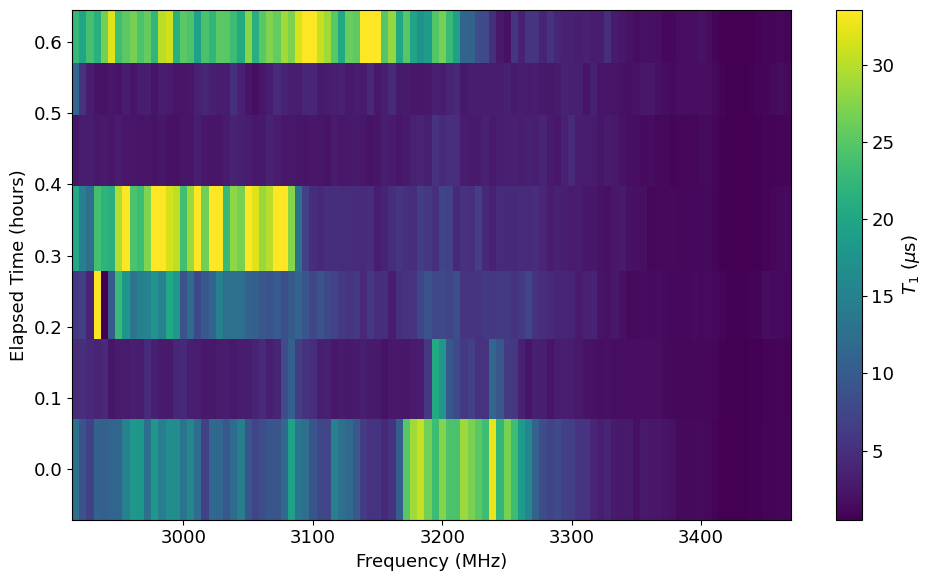

In [101]:
# Interpolate all scans onto a common frequency grid
# Use the scan with the most points as reference
from scipy.interpolate import interp1d

# Common grid: union range, resolution from densest scan
all_freq_min = min(f.min() for f in freq_rows)
all_freq_max = max(f.max() for f in freq_rows)
n_common = max(len(f) for f in freq_rows)
freq_common = np.linspace(all_freq_min, all_freq_max, n_common)

t1_grid = np.full((len(t1_rows), n_common), np.nan)
for i, (freq, t1) in enumerate(zip(freq_rows, t1_rows)):
    # Sort by frequency (ascending) for interpolation
    order = np.argsort(freq)
    interp = interp1d(freq[order], t1[order], bounds_error=False, fill_value=np.nan)
    t1_grid[i] = interp(freq_common)

# Elapsed time in hours from first scan
t0 = time_rows[0]
elapsed_hours = np.array([(t - t0).total_seconds() / 3600 for t in time_rows])

# Robust color limits
finite = t1_grid[np.isfinite(t1_grid)]
vmin, vmax = np.percentile(finite, [2, 98])

cmap = plt.cm.viridis.copy()
cmap.set_bad(color="0.45")

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(freq_common, elapsed_hours, t1_grid,
                   cmap=cmap, vmin=vmin, vmax=vmax, shading="auto", rasterized=True)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Elapsed Time (hours)")
plt.colorbar(im, ax=ax, label="$T_1$ ($\\mu$s)")
plt.tight_layout()
plt.show()

Gain = -0.24102, Freq ~ 3011.19 MHz


C:\Users\circu\AppData\Local\Temp\ipykernel_2188\1170543930.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, ncol=2, loc="best")


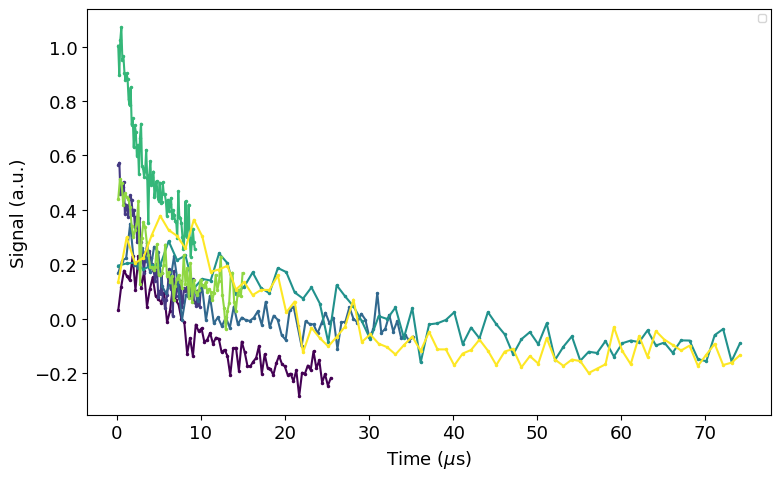

In [102]:
# Plot T1 decay curves at a specific gain across all scans
TARGET_GAIN = -0.24  # set desired gain value

from slab_qick_calib.analysis.fitting import expfunc

fig, ax = plt.subplots(figsize=(8, 5))
cmap_lines = plt.cm.viridis(np.linspace(0, 1, len(gain_rows)))

for i, (gains, xpts, scale, fit_p, t) in enumerate(
    zip(gain_rows, xpts_rows, scale_rows, fit_params_rows, time_rows)
):
    idx = np.argmin(np.abs(gains - TARGET_GAIN))

    actual_gain = gains[idx]
    #print(actual_gain)
    actual_freq = freq_rows[i][idx] if len(freq_rows[i]) > idx else np.nan

    x = xpts[idx]
    y = scale[idx]
    offset, amp, t1 = fit_p[0][idx], fit_p[1][idx], fit_p[2][idx]

    elapsed_h = (t - time_rows[0]).total_seconds() / 3600
    label = f"{elapsed_h:.1f}h (T1={t1:.2f})"

    ax.plot(x, y, ".-", ms=3, color=cmap_lines[i])
    # Plot fit curve
    # if np.isfinite(t1) and t1 > 0:
    #     x_fit = np.linspace(x.min(), x.max(), 100)
    #     ax.plot(x_fit, expfunc(x_fit, offset, amp, t1), "-",
    #             color=cmap_lines[i], lw=1, label=label)

ax.set_xlabel("Time ($\\mu$s)")
ax.set_ylabel("Signal (a.u.)")
ax.legend(fontsize=7, ncol=2, loc="best")
print(f"Gain = {actual_gain:.5f}, Freq ~ {actual_freq:.2f} MHz")
plt.tight_layout()
plt.show()

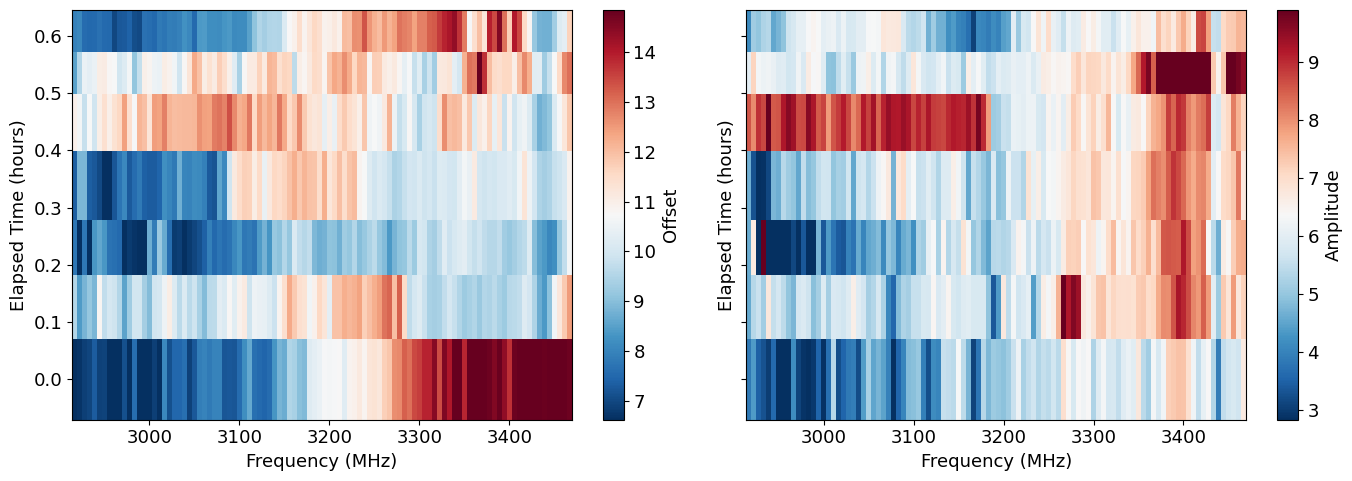

In [103]:
# Offset and Amplitude color plots (freq vs time)
offset_grid = np.full((len(t1_rows), n_common), np.nan)
amp_grid = np.full((len(t1_rows), n_common), np.nan)

for i, (freq, fit_p) in enumerate(zip(freq_rows, fit_params_rows)):
    order = np.argsort(freq)
    for grid, vals in [(offset_grid, fit_p[0]), (amp_grid, fit_p[1])]:
        f_interp = interp1d(freq[order], vals[order], bounds_error=False, fill_value=np.nan)
        grid[i] = f_interp(freq_common)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, grid, label in zip(axes, [offset_grid, amp_grid], ["Offset", "Amplitude"]):
    finite = grid[np.isfinite(grid)]
    vmin, vmax = np.percentile(finite, [2, 98])
    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color="0.45")
    im = ax.pcolormesh(freq_common, elapsed_hours, grid,
                       cmap=cmap, vmin=vmin, vmax=vmax, shading="auto", rasterized=True)
    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Elapsed Time (hours)")
    plt.colorbar(im, ax=ax, label=label)

plt.tight_layout()
plt.show()